<a href="https://colab.research.google.com/github/kataevadkkdasha-hub/project01/blob/main/%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82_%22%D0%A6%D0%9A_%D1%81%D0%BA%D0%B2%D0%BE%D0%B7%D0%BD%D0%BE%D0%B5_%D0%B7%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone Project: Predicting Survival on the Titanic

Решите задания в этом ноутбуке и ответьте на вопросы в тесте.

Основано на https://www.kaggle.com/competitions/titanic/

# Описание датасета

На датасете Titanic ставится задача бинарной классификации — по информации о пассажире предсказать, выживет пассажир или нет. Признаки в датасете следующие:

- **PassengerId** - id пассажира
- **Pclass** - класс обслуживания билета (1 = первый, 2 = второй, 3 = третий)
- **Name** - имя пассажира
- **Sex** - пол пассажира
- **Age** - возраст пассажира
- **SibSp** - семейные отношения sibling/spouse (sibling = брат, сестра, сводный брат, сводная сестра, spouse = муж, жена)
- **Parch** - семейные отношения parent/child (parent = родитель
child = ребенок). Некоторые дети путешествовали только с няней, поэтому для них parch=0.
- **Ticket** - номер билета
- **Fare** - стоимость билета
- **Cabin** - номер кабины
- **Embarked** - Порт посадки. (C = Шербур, Q = Квинстаун, S = Саутгемптон)

Целевая переменная:
- **Survived** - Выжил человек или нет. 0 = Нет, 1 = Да.

# Исследование структуры данных

**Цель**: Понять структуру и основные характеристики набора данных Титаника

In [103]:
# Загружаем необходимые библиотеки

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [104]:
# Загружаем данные с помощью библиотеки Pandas

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

Изучим содержимое датасета. Первые 5 строк:

In [105]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [106]:
# Посмотрим на типы столбцов.
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


### Задание 1
Сколько строк в наборе данных?

In [107]:
# ваш код здесь
len(df)

891

# Первичная обработка данных

### Задание 2
Есть ли колонки, которые не несут информации, и его можно удалить? Если да, удалите эту колонку

In [72]:
# ваш код здесь
#использовала этот код: df['PassengerId'].head(),df['PassengerId'].is_unique,del df['PassengerId']
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### Обработка пустых значений

### Задание 3
В каких колонках есть пропущенные значения?

In [73]:
# ваш код здесь
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Мы видим, что в столбце «Cabin» 77 % значений являются нулевыми, в то время как в столбце «Age» таких значений всего 20 %. Знание процента нулевых значений для каждого признака поможет избавиться от бесполезных признаков. В данном случае, поскольку в столбце «Cabin» много нулевых значений, его лучше удалить.

Удалите столбец «Cabin»

In [74]:
# ваш код здесь
# использовала для удаления этот код: del df['Cabin']
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Если в признаке мало пропущенных значений, мы можем попытаться заполнить их с помощью разных методов, либо удлаить строки с пропусками. Используем медиану для числовых признаков и моду для категориальных.

### Задание 4
Для признака Age замените пустые значения на медиану.
Для признака Embarked замените пустые значения на моду.

In [75]:
# ваш код здесь
# Использовала этот код: df['Age'].median(), df['Age'] = df['Age'].fillna(df['Age'].median()), df['Embarked'].mode(), df['Embarked'].mode()[0], df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0]), df.isnull().sum()
df['Age'].median()
df['Age'] = df['Age'].fillna(df['Age'].median())
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


# Разведочный анализ данных

Подробнее изучим распределение данных.

<Axes: xlabel='Survived', ylabel='count'>

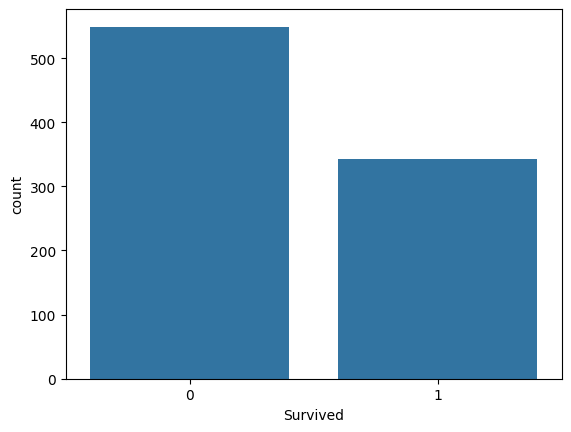

In [76]:
sns.countplot(x='Survived', data=df)

Наблюдаем небольшой дисбаланс классов - выживших меньше

## Анализ возраста

### Задание 5
Посмотрим на распределение смертей по возрасту. Какие можно сделать выводы, смотря на следующие графики?

Text(0.5, 1.0, 'Количество пассажиров по возрасту')

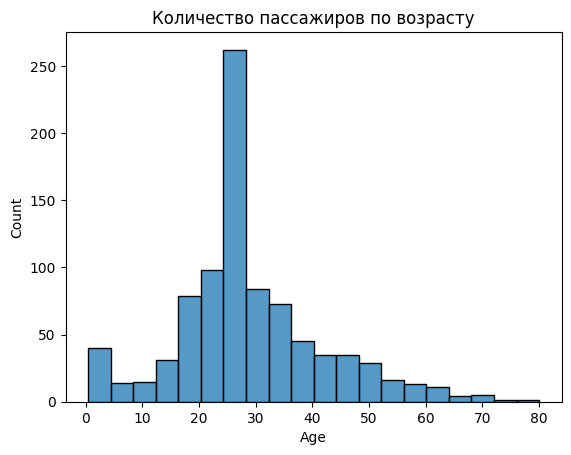

In [77]:
sns.histplot(data=df, x='Age', bins=20, kde=False)
plt.title('Количество пассажиров по возрасту')

<Axes: xlabel='Survived', ylabel='Age'>

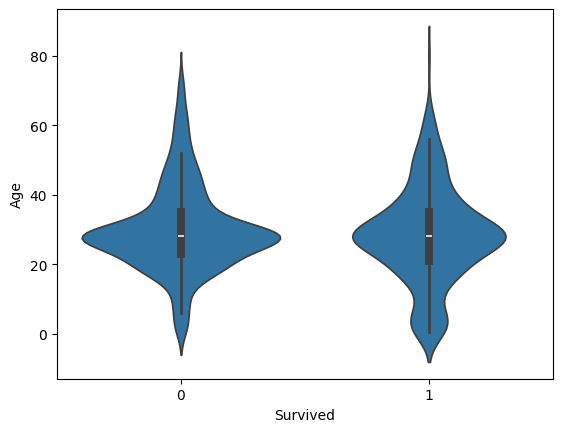

In [78]:
sns.violinplot(x='Survived', y='Age', data=df)
#Смотря на графики можно сделать вывод о том, что наибольшее количество пассажиров находятся в возрастном диапазоне 20-40 лет и что среди выживших много детей.
#Вместе с тем, среди погибших больше людей в диапазоне 20-40 лет, чем среди выживших.

## Изучение влияния гендера на целевую переменную

### Задание 6
Изучите следующие 2 графика. Какие можно сделать выводы о данных?

<Axes: xlabel='Survived', ylabel='count'>

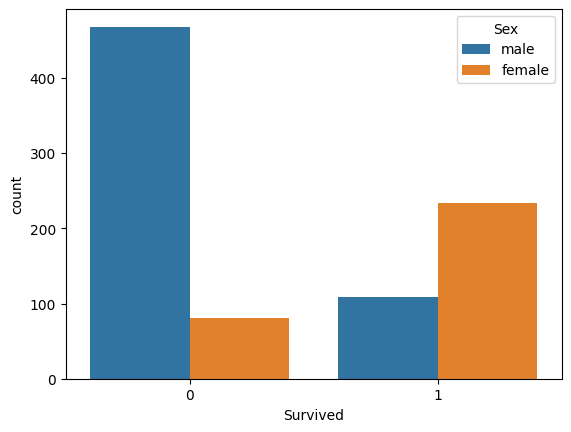

In [79]:
sns.countplot(x='Survived', hue='Sex', data=df)
#среди погибших больше мужчин, среди выживших больше женщин

С помощью скрипичного графика в Seaborn мы можем увидеть взаимосвязь между полом, возрастом и тем, выжил пассажир или нет.

<Axes: xlabel='Sex', ylabel='Age'>

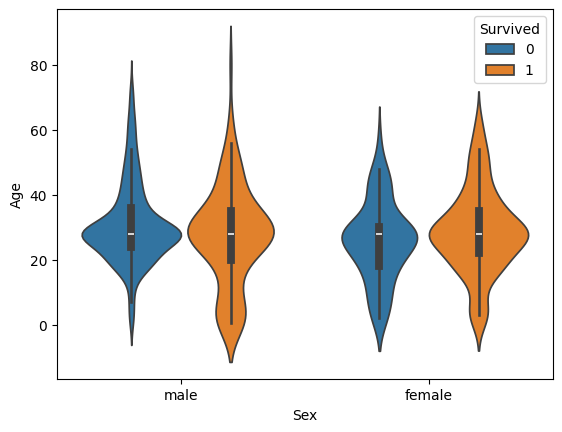

In [80]:
sns.violinplot(x='Sex', y='Age', hue='Survived', data=df)
#Среди мальчиков больше выживших, чем среди девочек (детей).В диапазон 20-40 лет погибло больше мужчин, чем женщин.
#Мужчин и женщин выжило больше, чем детей.

## Изучение влияния класса пасажира на целевую переменную

### Задание 7
Посмотрим на распределение смертей по классам. Какие можно сделать выводы, смотря на следующие графики?

<Axes: xlabel='Survived', ylabel='count'>

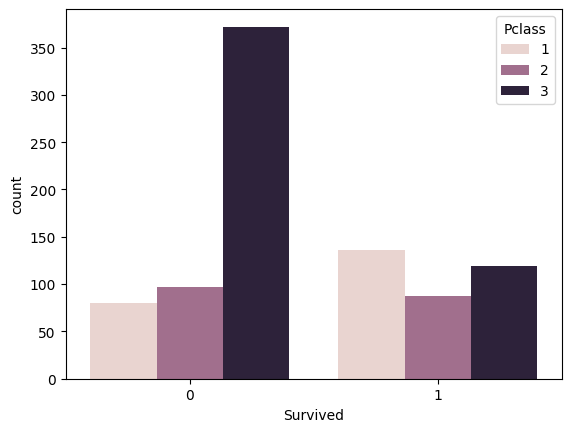

In [81]:
sns.countplot(x='Survived', hue='Pclass', data=df)
#Среди погибших много пассажиров 3-го класса (больше чем 1-го и 2-го вместе взятых).
#Среди выживших чуть больше пассажиров 1-го класса (примерно 150), меньше всего пассажиров 2-го(примерно 100), среди пассажиров 3-го класса выжило примерно 125 человек.

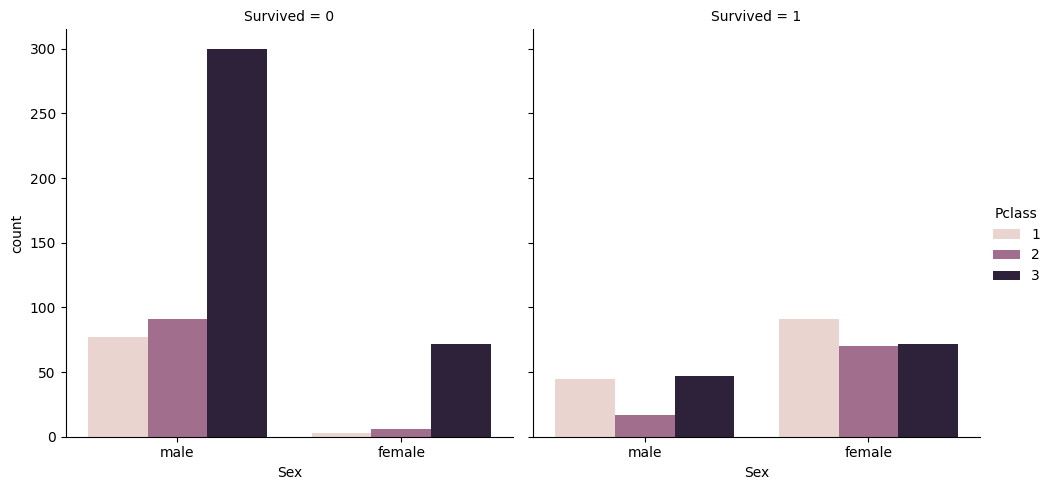

In [82]:
sns.catplot(x='Sex', hue='Pclass', col='Survived', kind='count', data=df)
#среди погибших всех классов больше мужчин, чем женщин (больше всего погибло мужчин 3-го класса).
#Среди выживших больше всего женщин (больше всего выжило женщин 1-го клаccа - даже фильм с Леонардо Ди Каприо тому потдверждение))


<Axes: xlabel='Pclass', ylabel='Age'>

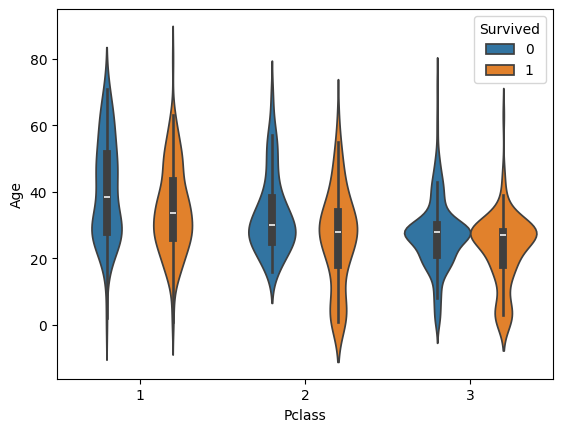

In [83]:
sns.violinplot(x='Pclass', y='Age', hue='Survived', data=df)
#Среди выживших 1-го класса больше всего людей 20-40 лет. Также в первом классе, судя по всему, было мало детей, но больше людей пожилого возраста, чем во втором и третьем классе.
#Среди погибших второго класса нет? погибших детей, больше погибших в возрасте 20-40 лет, чем выжвших
#Среди пассажиров третьего и второго класса большее количество детей выжило, а не погибло.

# Обработка данных

### Обработка категориальных переменных

Посмотрим внимательно на следующие столбцы. Там находятся не числа, а строки, когда остальные признаки являются числами.

In [92]:
df.describe(include='O')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


### Задание 8
Давайте преобразуем категориальных колонки с помощью метода One Hot Encoding. В колонках name и ticket слишком много уникальных значений, они не подойдут для применения этого метода. Что можно сделать с этими колонками обсудим в дополнительном блоке. Преобразуйте категориальные колонки Sex и Embarked с помощью метода One Hot Encoding. Для этого используйте метод get_dummies() с параметром drop_first=True

Сколько получилось колонок?

In [93]:
# ваш код здесь
#использовала этот код: df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

df.columns
df.shape[1]

14

## Генерация новых признаков

Линейные модели обладают рядом преимуществ, делающих их популярным инструментом в задачах машинного обучения:

- **Простота и скорость**. Они быстро обучаются даже на больших объёмах данных благодаря своей вычислительной эффективности.  
- **Интерпретируемость**. Вклад каждого признака в прогноз легко оценить по величине и знаку соответствующего коэффициента.

Однако у линейных моделей есть существенный недостаток: они предполагают, что признаки влияют на целевую переменную независимо друг от друга, а их вклады просто суммируются. Иными словами, модель не способна улавливать взаимодействия между признаками (например, совместное влияние возраста и пола на вероятность выживания), если эти взаимодействия не были явно заданы.

Для преодоления этого ограничения применяется **конструирование признаков (feature engineering)** — процесс создания новых переменных на основе исходных данных, который позволяет модели учитывать сложные зависимости. Например, можно добавить произведение двух признаков или их отношение, чтобы отразить их совместное влияние.

Однако важно помнить, что бессистемное добавление новых признаков без проверки их полезности может привести к переобучению, снижению обобщающей способности модели и увеличению вычислительной сложности. К конструированию признаков следует подходить осознанно, опираясь на понимание предметной области и результаты исследовательского анализа.

### Задание 9
Добавьте следующие признаки:
- family_members: количество членов семьи для каждого обьекта. Это результат сложения значений 'SibSp' и 'Parch' + 1 (как думаете, зачем +1?).
- single: указывает, есть ли у обьекта выборки семья (single). Это бинарная характеристика.

In [108]:
# ваш код здесь (+1 - потому что мы считаем размер семьи вместе с самим человеком)
df['family_members'] = df['SibSp'] + df['Parch'] + 1
df['single'] = (df['family_members'] == 1).astype(int)
df['family_members'].mean().round(3)

np.float64(1.905)

## Разбиение на обучающую и тестовую выборки

Для проверки качества модели в будущем, надо будет делать предсказаниях на обьектах выборки, которые модель не видела на этапе обучения. Для этого разделим данные на обучающую и тестовую выборку. Для начала сформируем из датафрейма матрицу признаков X и целевую переменную y. Из X необходимо удалить колонку с целевой переменной и категориальные колонки 'Name', 'Ticket'

In [109]:
y = df['Survived']

# Удаляем целевую переменную из матрицы признаков + категориальные признаки, которые мы не обработали
X = df.drop(columns=['Survived', 'Name', 'Ticket'])

### Задание 10
Разбейте признаки и целевую переменную на обучающую и тестовую выборку. Для этого используйте метод train_test_split, test_size укажите 0.25, а random_state раный 42 (константа RANDOM_STATE)

In [110]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

# Разбиваем данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test =  train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE
)
X_train.shape[0]

668

## Масштабирование признаков

Теперь нужно масштабировать признаки. Если мы возьмем два разных числовых признака, то обнаружим, что они имеют очень разную шкалу: например, возраст может достигать 80 лет, а у признака Pclass всего три значения (0, 1, 2). Такая разница в числовой шкале негативно сказывается на производительности моделей машинного обучения, мы это разбирали в 1 лекции. Поэтому необходимо провести масштабирование. Мы используем StandardScaler для масштабирования всех числовых признаков (X). В этом проекте метки (y) равны 0 или 1, поэтому их не нужно масштабировать.

### Задание 11
*  Обучите и преобразуйте (`fit_transform`) scaler на тренировочных данных
*  Преобразуйте (`transform`) тестовые данные

In [122]:
from sklearn.preprocessing import StandardScaler

# использовала этот код:
scaler = StandardScaler()
# scaled_X_train = scaler.fit_transform(X_train)
# После применения масштабирования матрица перестает быть объектом `pandas.DataFrame` - поэтому необходимо преобразование обратно в датафрейм
# X_train = pd.DataFrame(scaled_X_train, columns = X_train.columns)
# scaled_X_test = scaler.transform(X_test)
# X_test = pd.DataFrame(scaled_X_test, columns = X_test.columns)
# round(X_train['Age'].max(), 3)

# Обучение модели

В данной части задания, мы хотим научиться обучать модели для задачи классификации на наших данных.

Начнем с обучения линейной модели
### Задание 12
Обучите модель Логистической регрессии.
1. Создайте модель используя `LogisticRegression` с гиперпараметрами `random_state` 42 (константа RANDOM_STATE), `max_iter` равный 1000
2. Вызовите метод `fit`, указав в параметрах данные для обучения (X_train и y_train)

In [124]:
from sklearn.linear_model import LogisticRegression
# использовала этот код: model = LogisticRegression(random_state=42, max_iter=1000)
# model.fit(X_train, y_train)

## Оценка качества модели

Для оценки качества модели будем оценивать метрику accuracy - это доля объектов, для которых мы правильно предсказали класс

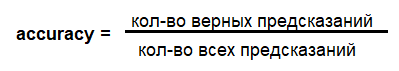

### Задание 12
Посчитайте значение метрики accuracy с помощью метода accuracy_score

In [127]:
from sklearn.metrics import accuracy_score

# Предсказание на тестовой выборке
# y_pred = model.predict(X_test)

# acc = accuracy_score(y_test, y_pred)
# print(f"Accuracy модели: {acc:.4f}")

### Задание 13
Попробуем решить задачу с помощью дргуих моделей

Обучите модели из списка предложенных моделей из библиотеки `sklearn` с указанными гиперпараметрами. Какая из них показала лучшие метрики?
* KNeighborsClassifier (укажите n_neighbors=3)
* DecisionTreeClassifier (укажите random_state=RANDOM_STATE)
* RandomForestClassifier (укажите random_state=RANDOM_STATE)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# model = KNeighborsClassifier(n_neighbors=3)
# model.fit(X_train, y_train)
# y_pred = model.predict(X_test)
# # print(f"Accuracy KNN: {acc:.4f}")

In [ ]:
from sklearn.tree import DecisionTreeClassifier
# model = DecisionTreeClassifier(random_state=42)
# model.fit(X_train, y_train)
# y_pred = model.predict(X_test)
# acc = accuracy_score(y_test, y_pred)
# print(f"Accuracy Decision Tree: {acc:.4f}")

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# model = RandomForestClassifier(random_state=42)
# model.fit(X_train, y_train)
# y_pred = model.predict(X_test)
# acc = accuracy_score(y_test, y_pred)
# print(f"Accuracy Random Forest: {acc:.4f}")

### Задание 14
Попробуйте подобрать гиперпараметр n_neighbors (кол-во ближайших соседей для предсказания) для модели KNN.

Обучите модель KNeighborsClassifier со значениями 3, 4, 5, 6, 7. С каким значением гиперпараметра модель показала себя лучше?

In [129]:
from sklearn.neighbors import KNeighborsClassifier
# for k in [3,4,5,6,7]:
    # model = KNeighborsClassifier(n_neighbors=k)
    # model.fit(X_train, y_train)
    # print(k, accuracy_score(y_test, model.predict(X_test)))

# Дополнительные блоки

In [ ]:
X_new = df.copy()

Давайте попробуем сделать признак чуть посложнее. Посмотрим на колонку name. Перед именем пассажира стоит приставка титула. Подумайте, в какой признак можно преобразовать эту колонку?

In [ ]:
X_new["Name"]

### ВНИМАНИЕ! ответ на вопрос выше

Можно попробовать получить инфрамацию о статусе пассажира, например, так

In [ ]:
# Извлечение титула из имени с использованием векторных операций pandas
# Предполагается, что формат имени: "Фамилия, Титул. Имя" (стандарт для Titanic)
X_new['Title'] = X_new['Name'].str.split(',').str[1].str.split('.').str[0].str.strip()

# Список редких титулов, которые будут объединены в категорию "Rare"
rare_titles = ['Lady', 'the Countess', 'Countess', 'Capt', 'Col', 'Don',
               'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']

# Замена редких титулов на 'Rare'
X_new['Title'] = X_new['Title'].replace(rare_titles, 'Rare')
X_new['Title']

Мы получили новый категориальный признак. Как его можно закодировать?

#### Ответ на вопрос выше

Здесь можно использовать Label Encoding

In [ ]:

# Словарь для числового кодирования
title_mapping = {
    'Master': 0,
    'Miss': 1,
    'Ms': 1,
    'Mme': 1,
    'Mlle': 1,
    'Mrs': 1,
    'Mr': 2,
    'Rare': 3
}

# Применяем отображение; если какой-то титул не найден в словаре, он станет NaN
X_new['Title'] = X_new['Title'].map(title_mapping)

# Проверяем, есть ли пропущенные значения (непредусмотренные титулы)
if X_new['Title'].isna().any():
    print("Обнаружены неизвестные титулы. Заполняем их значением 'Rare' (3).")
    X_new['Title'] = X_new['Title'].fillna(3)

# Удаляем исходный столбец Name
X_new = X_new.drop('Name', axis=1)

 Пояснение метода Label Encoding

В данном коде мы используем **Label Encoding** категориального признака `Title`.

**Почему выбран именно такой подход?**  

1. **Экономия памяти и размерности**  
   В отличие от **one-hot encoding**, который создаёт множество бинарных столбцов (по одному на каждую категорию), словарное кодирование оставляет один числовой столбец. Это особенно важно, если категорий много (здесь их всего 4 после объединения). Модель не страдает от "проклятия размерности", и данные остаются компактными.

2. **Возможность задать порядок (если он есть)**  
   Хотя титулы сами по себе не имеют строгого порядка, мы можем искусственно ввести упорядочение, если это полезно для модели. Например, можно считать, что чем выше титул, тем выше шанс на выживание (Master < Miss/Mrs < Mr < Rare). Данный подход допустимо использовать, когда мы можем так или иначе ранжировать значения, так как модель будет воспринимать что класс Miss меньше Rare на 2

Для категорий, не имеющих порядка (например, цвета, страны, названия городов), Label Encoding может быть опасен. Алгоритм машинного обучения может подумать, что между числами существует математическая зависимость (например, что Синий (2) больше, чем Красный (0) или что Синий — это среднее между Красным и Зеленым), что часто приводит к ухудшению качества модели.

### Признак Ticket

А какой признак можно получить из признака Ticket?

In [ ]:
X_new['Ticket']

### ВНИМАНИЕ! Ответ на вопрос выше

Можно извлечь категориальный признак из номера билета, а именно — буквенный префикс, который может указывать на тип, серию или класс билета.

В данных «Титаника» номера билетов часто содержат буквенную часть (например, PC 17599, SOTON.O.Q., CA. 2343), а иногда состоят только из цифр.

Колонка имеет небольшое количество уникальных признаков, поэтому можно извлечь префикс и обработать его с помощью one-hot encoding

In [ ]:
def extract_ticket_prefix(ticket):
    cleaned = ticket.replace('.', '').replace('/', '').strip()
    # Берём первую группу символов до пробела
    if not ticket.isdigit():
        prefix = cleaned.split(' ')[0]
        return prefix

X_new['Ticket'] = X_new['Ticket'].apply(extract_ticket_prefix)

# Заполним пустые значения новым классом - NaN
X_new['Ticket'] = X_new['Ticket'].fillna('NaN')
X_new = pd.get_dummies(df, columns=['Ticket'], drop_first=True, prefix='T')

In [ ]:
df['Ticket']

In [ ]:
ticket = []
for i in list(X_new.Ticket):
    if not i.isdigit() :
        ticket.append(i.replace('.', '').replace('/', '').strip().split(' ')[0])
    else:
        ticket.append('X')
X_new['Ticket'] = ticket
X_new['Ticket'].head()
train_dummies = pd.get_dummies(X_new['Ticket'], prefix='T')
X_new = pd.concat([X_new, train_dummies], axis=1).drop('Ticket', axis=1)

In [ ]:
from sklearn.model_selection import train_test_split

# Разбиваем данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_new.drop(columns=['Survived']), y, test_size=0.25, random_state=42
)


### Попробуйте обучить модель с новыми признаками

Не забудьте процесс:
1. Разделить на обучающую и тестовую выборку
2. Отмасшиабировать признакми
3. Обучить модель
4. Посчитать метрики

С новыми признаками модель улучшила свое качество?

Если интересно, как можно решить задачу с помощью нейросетей, почитать можно [тут](https://habr.com/ru/articles/726454/#net)